## Wind Resource and Energy Yield Assessment: Hohn, Schleswig-Holstein

This notebook walks through a **wind energy yield assessment** for a hypothetical five-turbine wind farm. The story: imagine that the Hohn airfield has been decommissioned and the land is going to be used for wind energy. The project would look like this:


In [1]:
# --- Imports -------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from windforecast import config
from windforecast.io.dwd import load_hourly_wind

cfg = config.load()

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 25)

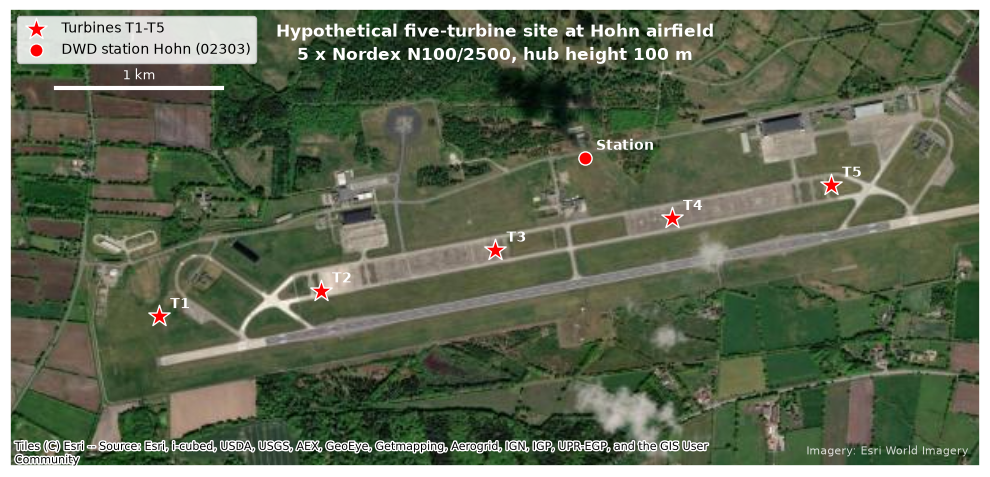

In [2]:
# --- Site map: turbine layout on satellite imagery ------------------------
import geopandas as gpd
import contextily as cx

from windforecast.paths import FIGURES

site = cfg["site"]

turbines = gpd.GeoDataFrame(
    {"name": [t["name"] for t in site["turbines"]]},
    geometry=gpd.points_from_xy(
        [t["longitude"] for t in site["turbines"]],
        [t["latitude"] for t in site["turbines"]],
    ),
    crs="EPSG:4326",
).to_crs(3857)

station = gpd.GeoDataFrame(
    {"name": [f"DWD {site['name']} (02303)"]},
    geometry=gpd.points_from_xy([site["longitude"]], [site["latitude"]]),
    crs="EPSG:4326",
).to_crs(3857)

fig, ax = plt.subplots(figsize=(10, 9))

# extent: bounding box of all points, padded
pad = 900  # m
xmin, ymin, xmax, ymax = gpd.pd.concat([turbines, station]).total_bounds
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, crs=turbines.crs, zoom=14)

turbines.plot(ax=ax, marker="*", color="red", markersize=260,
              edgecolor="white", linewidth=1.0, label="Turbines T1-T5")
station.plot(ax=ax, marker="o", color="red", markersize=90, edgecolor="white",
             label="DWD station Hohn (02303)")

for pt, name in zip(turbines.geometry, turbines["name"]):
    ax.annotate(name, (pt.x, pt.y), xytext=(8, 6), textcoords="offset points",
                color="white", fontsize=10, fontweight="bold")

ax.annotate("Station", (station.geometry.iloc[0].x, station.geometry.iloc[0].y),
            xytext=(8, 6), textcoords="offset points",
            color="white", fontsize=10, fontweight="bold")

# title inside the frame
ax.set_title("")
ax.text(0.5, 0.975,
        f"Hypothetical five-turbine site at Hohn airfield\n"
        f"{site['turbine_count']} x {cfg['turbine']['model']}, "
        f"hub height {cfg['turbine']['hub_height_m']} m",
        transform=ax.transAxes, ha="center", va="top",
        color="white", fontsize=12, fontweight="bold", linespacing=1.4)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("white")
    spine.set_linewidth(1.2)

legend = ax.legend(loc="upper left", framealpha=0.85)

# scale bar, centered just below the legend box
bar_m = 1000
fig.canvas.draw()                                   # legend extent is known only after a draw
lb = legend.get_window_extent().transformed(ax.transAxes.inverted())
bar_frac = bar_m / (ax.get_xlim()[1] - ax.get_xlim()[0])
xc = (lb.x0 + lb.x1) / 2 - 0.03
xa0, xa1 = xc - bar_frac / 2, xc + bar_frac / 2
ya = lb.y0 - 0.025
ax.plot([xa0, xa1], [ya, ya], color="white", lw=3, transform=ax.transAxes)
ax.annotate("1 km", (xc, ya), xycoords="axes fraction", xytext=(0, 6),
            textcoords="offset points", ha="center", color="white", fontsize=9)

ax.annotate("Imagery: Esri World Imagery", (xmax + pad, ymin - pad),
            xytext=(-8, 8), textcoords="offset points", ha="right",
            color="white", fontsize=8, alpha=0.8)

fig.tight_layout()
fig.savefig(FIGURES / "site_map_hohn.png", dpi=500, bbox_inches="tight")
plt.show()


Five Nordex N100/2500 turbines (100 m rotor, 100 m hub height) stand in a single row along the airfield, oriented roughly WSW–ENE. The row is about 2.4 km long, with 570–630 m between neighbouring turbines, which is about 6 rotor diameters.

Before anything gets built, the site has to be assessed: how much wind is there, and how much energy would five turbines actually produce over their lifetime?

A real project would start with an on-site measurement campaign, usually a met mast or lidar recording wind for at least a year. I don't have one, so this study pretends it does. **The Deutscher Wetterdienst (DWD) station Hohn (02303), just north of the row, stands in for the site measurement.** Two years of its data (2021–2022) are treated as if they came from our own campaign. It's not ideal: the anemometer is at 10 m rather than near hub height, and the station was never sited for this purpose (more on this in Step 1). 

Of course, a measurement campaign alone, real or pretend, doesn't get us very far. There are quite a few pieces missing, and putting the puzzle together takes a few more steps. The table below gives an overview of what it takes to get to the energy yield of this wind farm. The steps follow the MEASNET guideline for site assessment [2] and the DFBEW / Fraunhofer IWES background paper [1], which reviews how these methods are used in practice. Both are cited throughout the notebook (see References below).


| Step | What happens | DFBEW [1] | MEASNET [2] | WindPRO |
|---|---|---|---|---|
| 1 | Measurement campaign: DWD Hohn, 10 m → 100 m | II.1 | M 8.2, M 9.4 | METEO |
| 2 | Long-term reference: COSMO-R6G2, 2002–2025 | II.3.2 | M 8.3.4 | MCP |
| 3 | Long-term correction: sector-wise MCP | II.3.1 | M 8.3.2 | MCP |
| 4 | Horizontal transfer to each turbine (Global Wind Atlas) | II.4 | M 8.4 | MODEL / WAsP |
| 5 | Air density at hub height (COSMO) | II | M 9.2 | METEO / PARK |
| 6 | Gross energy yield, per turbine and for the farm | II.5 | M 10.2 | PARK |

Losses (wakes, availability, curtailment) and the uncertainty budget (DFBEW II.5 and III, MEASNET 8.6 and 10.3) come after this and aren't covered yet. So the number at the end is a **gross** yield.

**Everything here uses public data and open-source tools**. WindPRO, the industry standard for this kind of project, isn't used, but it does make everything easier, and the table above also shows which WindPRO module would normally do each step. 

**References**

I used many references for this project. The ones that are cited here are:

- \[1\] Basse, A., Callies, D., Hahn, B. (2017). *Windmessungen und Windgutachten für die Standortbewertung von Windenergieanlagen an Land: Methoden und Analyse.* Hintergrundpapier, DFBEW / Fraunhofer IWES.
- \[2\] MEASNET (2022). *MEASNET Procedure: Evaluation of Site-Specific Wind Conditions.* Version 3, September 2022.
- \[3\] Floors, R., Nielsen, M. (2019). Estimating Air Density Using Observations and Re-Analysis Outputs for Wind Energy Purposes. *Energies* 12(11), 2038. https://doi.org/10.3390/en12112038
- \[4\] Waars, N. D. (2017). *Lidar and MCP in Wind Resource Estimations above Measurement-Mast Height.* MSc thesis, DTU Wind Energy / TU Delft.
- \[5\] Lázár, I., Hadnagy, I., Bertalan-Balázs, B., Bertalan, L., Szegedi, S. (2024). Comparative examinations of wind speed and energy extrapolation methods using remotely sensed data – A case study from Hungary. *Energy Conversion and Management: X* 24, 100760. https://doi.org/10.1016/j.ecmx.2024.100760
- \[6\] Staffell, I. (no date). *Wind Turbine Power Curves.*, Imperial College London.


Data: DWD Climate Data Center (station 02303 Hohn) · DWD COSMO-R6G2 reanalysis (CC BY 4.0) · Global Wind Atlas, DTU Wind Energy (CC BY 4.0).

## Step 1 — The measurement campaign (Winddatenbasis · DFBEW II.1 · MEASNET 8.2)

Before you build anything, you measure. As mentioned before, our pretend campaign is not ideal. The problem is height: DWD measures at 10 m, and the hubs of our Nordex N100 are at 100 m. The industry standard today is increasingly lidar, which measures straight up to hub height and beyond, so nobody has to guess how the wind changes above the instrument. DFBEW II.1 asks for a measurement height of at least two thirds of hub height if you extrapolate vertically (more on that below). 10 m is one tenth. **In a real project this wouldn't be accepted.** Here it's fine though, because the point is to practise the steps, not to get a bankable number.

The guidelines also ask for a campaign of at least 12 months, with around 90 % availability and no long gap that removes part of a season (MEASNET 8.3.2). Let's download the data for the years 2021 and 2022 from Hohn directly from DWD and check if it's good enough to use:


In [3]:
# --- Download DWD data:  -----------------------------------------------------

# from windforecast.download.dwd import main as download_dwd
# download_dwd()   # writes into data/raw/dwd/, skips files already there


In [4]:
# `load_hourly_wind` handles the DWD conventions: `-999` → NaN, MEZ → UTC, a complete hourly axis, 
# and direction codes `0` (calm) and `990` (variable) set to missing.

# Columns:
#   F      mean wind speed at 10 m (m/s)
#   D      wind direction, degrees (0/990 codes and calms -> NaN)
#   D_raw  direction as DWD delivers it
#   QN_3   DWD quality level of the measurement

dwd = cfg["reference_data"]["dwd"]
window = cfg["analysis"]["measurement_window"]
WINDOW = (str(window["start"]), str(window["end"]))

measured = load_hourly_wind(dwd["primary"],                       # load the station data
                            time_base=dwd["time_base"])           # convert MEZ to UTC
measured = measured.loc[WINDOW[0]:f"{WINDOW[1]} 23:00"]           # keep only the measurement window (2 years)


# check for missing data
hours_expected = len(pd.date_range(WINDOW[0], f"{WINDOW[1]} 23:00", freq="h"))
hours_speed = measured["F"].notna().sum()
hours_direction = measured["D"].notna().sum()

share_speed = 100 * hours_speed / hours_expected
share_direction = 100 * hours_direction / hours_expected
share_worst_month = 100 * (measured["F"].notna()
                           .groupby([measured.index.year, measured.index.month])
                           .mean().min())

display(Markdown(f"""
| | Hours w.<br>Measurements | Availability |
|---|---:|---:|
| Expected (2021–2022) | {hours_expected} | |
| With wind speed | {hours_speed} | {share_speed:.2f} % |
| With wind direction | {hours_direction} | {share_direction:.2f} % |
| Worst calendar month | | {share_worst_month:.2f} % |

Availability is {share_speed:.2f} % for speed and {share_direction:.2f} % for direction, comfortably above 80 %. So our "campaign" went very well!


"""))



| | Hours w.<br>Measurements | Availability |
|---|---:|---:|
| Expected (2021–2022) | 17520 | |
| With wind speed | 17497 | 99.87 % |
| With wind direction | 17488 | 99.82 % |
| Worst calendar month | | 97.22 % |

Availability is 99.87 % for speed and 99.82 % for direction, comfortably above 80 %. So our "campaign" went very well!




Next, we need to deal with the height problem. We will calculate the expected wind at 100 m from our 10 m measurement. That will be done using the logarithmic wind profile (method V2 in Lázár et al. [5]):

$$v_2 = v_1 \cdot \frac{\ln(h_2 / z_0)}{\ln(h_1 / z_0)}$$

with $v_1$ the measured speed at $h_1 = 10$ m, $v_2$ the speed at hub height $h_2 = 100$ m, and $z_0$ the roughness length.

$z_0$ has to be chosen; it isn't measured. I take the values from the roughness classes in Lázár et al. [5], Table 2. The station sits on an open airfield surrounded by grassland, as seen in the satellite image above, so from 75° to 285° I use $z_0 = 0.008$ m ("grassland"). To the north there's a forest, so from 285° through north to 75° I use $z_0 = 0.5$ m ("mature forest or settlement with small differences in height").

In [5]:
from windforecast.analysis.profile import add_z0, log_extrapolate

z0_sectors = [(s["from_deg"], s["to_deg"], s["z0_m"]) for s in cfg["analysis"]["roughness"]["sectors"]]
measured = log_extrapolate(df=add_z0(df=measured, sectors=z0_sectors),
                           speed_col="F", z0_col="z0", from_height=10, to_height=100)

display(measured[["F", "F100_extrapol"]].describe())

u10, u100 = measured["F"].mean(), measured["F100_extrapol"].mean()
display(Markdown(f'We have our measured wind at 100 m now. The mean wind at 10 m is **{u10:.2f} m/s**, and at 100 m it is **{u100:.2f} m/s**, showing why the higher the better for wind turbines. '
                 f'Two years is nothing in climate terms, though, and one windy year can make a site look great! But the turbines will run for about 20 years, meaning we need a long-term record to put our short measurement into context. '
                 f'And that is exactly what Steps 2 and 3 do!'))


,F,F100_extrapol
count,17497.000000,17488.000000
mean,3.803389,5.477197
std,2.428695,3.618558
min,0.100000,0.132290
25%,2.000000,2.778095
50%,3.300000,4.630159
75%,5.100000,7.408254
max,19.300000,27.767362


We have our measured wind at 100 m now. The mean wind at 10 m is **3.80 m/s**, and at 100 m it is **5.48 m/s**, showing why the higher the better for wind turbines. Two years is nothing in climate terms, though, and one windy year can make a site look great! But the turbines will run for about 20 years, meaning we need a long-term record to put our short measurement into context. And that is exactly what Steps 2 and 3 do!

## Step 2 — The long-term reference (Langzeitreferenz · DFBEW II.3.2 · MEASNET 8.3.4)

Step 2 is simple: all we need is to find a suitable long-term reference and download it. The guidelines ask for three things: it should be close to the site ("wenige Kilometer"), longer than ten years (20–30 in parts of the literature), and overlapping the measurement period (DFBEW II.3.2; MEASNET 8.3.4 calls ten years a reasonable compromise).

COSMO-R6G2, DWD's regional reanalysis, ticks all three boxes. Its 6 km grid puts the centre of the cell containing the station just 3.5 km away. It gives hourly wind at 100 m from 2002 to 2025, so 24 years, and those include our two measurement years. On top of that, it's open data (CC BY 4.0). So we download it directly from the website:

<details>
<summary>Note on the download</summary>

The download is the only awkward part. COSMO-R6G2 covers all of Europe in 824 × 848 cells, and we only need one of them: the cell containing the station, which `nearest_cell` finds on the rotated-pole grid. But the server has no spatial subsetting, so you can't ask for a single cell. The smallest unit on offer is one month of the whole European domain as a single `.nc4` file. So each month is downloaded whole, the one cell is extracted and appended to a CSV, and the `.nc4` is deleted before the next month starts. Only the CSV is kept. **That's what the next cell does (commented out, since the CSVs already exist).**

</details>


In [6]:
# --- Download COSMO SP_100 and DD_100m: -----------------------------------------
# from windforecast.download.cosmo import download_group

# download_group(
#     cfg["reference_data"]["cosmo"]["base_url"],
#     "hourly_zlev",
#     ["SP_100m", "DD_100m"],
#     site["latitude"], site["longitude"],
# )   # skips months already in the CSV; writes data/raw/cosmo/hourly_zlev/<var>/cosmo_<var>.csv


Then we load wind speed and direction at 100 m. To help with the next step, I will already assign every hour to a direction sector: 12 sectors of 30°, with sector 0 centred on north (345°–15°), sector 1 on 30°, and so on. Why this matters becomes clear in Step 3, but in short, it makes the correlation better.


In [7]:
from windforecast.paths import RAW_COSMO_HOURLY

sp = pd.read_csv(RAW_COSMO_HOURLY / "SP_100m" / "cosmo_SP_100m.csv", index_col="time", parse_dates=True)
dd = pd.read_csv(RAW_COSMO_HOURLY / "DD_100m" / "cosmo_DD_100m.csv", index_col="time", parse_dates=True)

cosmo = pd.concat([sp.iloc[:, 0].rename("SP_100m"),
                   dd.iloc[:, 0].rename("DD_100m")], axis=1)

# 12 sectors of 30°, sector 0 = 345°–15°
cosmo["sector"] = (((cosmo["DD_100m"] + 15) % 360) // 30).astype("Int64")
display(cosmo.describe())

u_cosmo_lt = cosmo["SP_100m"].mean()
u_cosmo_window = cosmo.loc[WINDOW[0]:f"{WINDOW[1]} 23:00", "SP_100m"].mean()

display(Markdown(f"""
Now our COSMO data is ready. It gives us {len(cosmo):,} hours of wind at 100 m, from {cosmo.index.min():%Y} to {cosmo.index.max():%Y},
with a mean of **{u_cosmo_lt:.2f} m/s**. Over our two measurement years alone it averages {u_cosmo_window:.2f} m/s,
about {100 * (u_cosmo_window / u100 - 1):.0f} % more than our extrapolated measurement ({u100:.2f} m/s) over the same period.
For the MCP itself the gap doesn't matter: the regression is fitted to our measurement, so COSMO only tells us how windy the long term was *compared to* 2021–2022.
But a gap this size is relevant and also a hint that the extrapolation may underestimate the wind. More on that in Step 4.
"""))


,SP_100m,DD_100m,sector
count,210383.000000,210383.000000,210383.0
mean,7.048203,198.480135,6.437212
std,3.312773,88.598052,3.003677
min,0.042528,0.073403,0.0
25%,4.707938,122.244534,4.0
50%,6.828816,214.920135,7.0
75%,9.011185,270.051575,9.0
max,28.652971,359.925873,11.0



Now our COSMO data is ready. It gives us 210,383 hours of wind at 100 m, from 2002 to 2025,
with a mean of **7.05 m/s**. Over our two measurement years alone it averages 6.78 m/s,
about 24 % more than our extrapolated measurement (5.48 m/s) over the same period.
For the MCP itself the gap doesn't matter: the regression is fitted to our measurement, so COSMO only tells us how windy the long term was *compared to* 2021–2022.
But a gap this size is relevant and also a hint that the extrapolation may underestimate the wind. More on that in Step 4.


We have the two pieces now, and Step 3 will put them together, or rather, correlate them.

## Step 3 — Long-term correction with MCP (Langzeitkorrektur · DFBEW II.3.1 · MEASNET 8.3.2)

Back to the question from Step 1: were 2021 and 2022 good wind years at Hohn, bad ones, or just average? Our measurement alone can't tell us, but COSMO can, and it lets us get a sense of the site's long-term wind climate without measuring for decades.

There are two families of long-term correction: MCP (Measure–Correlate–Predict) and long-term scaling (DFBEW II.3.1, MEASNET 8.3.2). Scaling is the simpler of the two and works with monthly data, but it can only relate integral values such as monthly means or Weibull parameters, so it has to assume that the wind directions and the shape of the distribution during the measurement are typical for the long term (MEASNET 8.3.2). With hourly COSMO data available, **I use MCP**: take the hours where both series exist, find a relationship between them, then apply that relationship to all 24 years of COSMO.


For the "correlate" part there are several methods; Waars [4], §2.3.1, gives a nice overview (linear regression, variance ratio, Mortimer, matrix methods, …). **I use the sector-wise regression** ("Sectoral Regression MCP" in MEASNET 8.3.2): a straight line $u_\text{site} = a + b\,u_\text{ref}$, fitted separately for each of the 12 sectors.

Why sectors? The relationship between our measurement and COSMO isn't the same for every direction, since the wind comes from different weather situations and passes over different terrain (forest to the north, open grassland elsewhere). The sectors are defined by COSMO's wind direction, since for the 22 years without measurements that's the only direction we have. One caveat: linear regression gets the mean wind speed right but predicts a slightly too narrow distribution, which the variance ratio method avoids (Waars [4], §2.3.1).

In [8]:
# Joining measurement and COSMO in one data frame:

short = measured["F100_extrapol"]           # measurement
ref = cosmo["SP_100m"]                      # COSMO
sect = cosmo["sector"]

both = pd.concat({"T": short, "R": ref, "sect": sect}, axis=1).dropna()

In [9]:
import statsmodels.api as sm

# correlate: one linear regression per sector
rows = {}
for s, g in both.groupby("sect"):
    model = sm.OLS(g["T"], sm.add_constant(g["R"])).fit()
    rows[s] = {"a": model.params["const"], "b": model.params["R"],
               "r": g["T"].corr(g["R"]), "n": len(g)}
coef = pd.DataFrame(rows).T

display(coef.round(3))

,a,b,r,n
0,1.050,0.725,0.622,538.0
1,0.352,0.932,0.681,627.0
2,-0.484,1.253,0.803,1068.0
3,0.042,0.891,0.756,1408.0
4,0.472,0.590,0.726,1279.0
5,0.954,0.349,0.637,1070.0
6,0.315,0.478,0.711,1300.0
7,-0.376,0.638,0.830,1941.0
8,-0.239,0.715,0.873,2169.0
9,-0.093,0.904,0.823,2434.0


These are the regression coefficients for each of our 12 sectors: the intercept *a*, the slope *b*, the correlation *r* between our measurement and COSMO, and *n*, the number of hours that went into each fit. That last column matters more than it looks. A sector with only a few hundred hours gives a much shakier line than one with several thousand, which is the sampling problem Waars [4] warns about when sectors get narrow. MEASNET 8.3.2 asks for exactly this table, so it stays in.

Now for the "predict" part: every hour of the 24 years of COSMO gets the *a* and *b* of its sector, and out comes our long-term time series.


In [10]:
# predict: each long-term hour gets the a, b of its sector
cosmo_sec = cosmo["sector"]
predicted_sec = pd.DataFrame({
    "u": (cosmo_sec.map(coef["a"]) + cosmo_sec.map(coef["b"]) * cosmo["SP_100m"]).clip(lower=0),
    "sector": cosmo_sec,
})


# numbers for the text
NAMES = ["north", "north-north-east", "east-north-east", "east", "east-south-east", "south-south-east",
         "south", "south-south-west", "west-south-west", "west", "west-north-west", "north-north-west"]
s_min, s_max = int(coef["r"].idxmin()), int(coef["r"].idxmax())
r_w = (coef["r"] * coef["n"]).sum() / coef["n"].sum()
share_good = 100 * coef.loc[coef["r"] >= 0.8, "n"].sum() / coef["n"].sum()
u_lt = predicted_sec["u"].mean()
diff = 100 * (u_lt / u100 - 1)

display(Markdown(f"""
Per sector, r ranges from {coef['r'].min():.2f} (sector {s_min}, {NAMES[s_min]}) to {coef['r'].max():.2f}
(sector {s_max}, {NAMES[s_max]}). Weighted by the number of hours, the mean r is {r_w:.2f},
{'a bit below' if r_w < 0.8 else 'above'} the 0.8 that MEASNET 8.3.2 recommends, and {share_good:.0f} % of the hours
fall in sectors that reach it. Not surprising for a 10 m station lifted to 100 m with a formula,
but worth remembering for the uncertainty budget later.

So, were our two years normal? The measurement averaged {u100:.2f} m/s at 100 m, and the 24-year long-term series
averages {u_lt:.2f} m/s. The measurement period was about {abs(diff):.0f} % {'calmer' if diff > 0 else 'windier'}
than usual, so without this step we would have {'under' if diff > 0 else 'over'}estimated the wind by about that much,
and the energy by roughly twice that.

Here's what the long-term wind looks like: where it comes from and how strong it is.
"""))


Per sector, r ranges from 0.62 (sector 0, north) to 0.87
(sector 8, west-south-west). Weighted by the number of hours, the mean r is 0.78,
a bit below the 0.8 that MEASNET 8.3.2 recommends, and 58 % of the hours
fall in sectors that reach it. Not surprising for a 10 m station lifted to 100 m with a formula,
but worth remembering for the uncertainty budget later.

So, were our two years normal? The measurement averaged 5.48 m/s at 100 m, and the 24-year long-term series
averages 5.62 m/s. The measurement period was about 3 % calmer
than usual, so without this step we would have underestimated the wind by about that much,
and the energy by roughly twice that.

Here's what the long-term wind looks like: where it comes from and how strong it is.


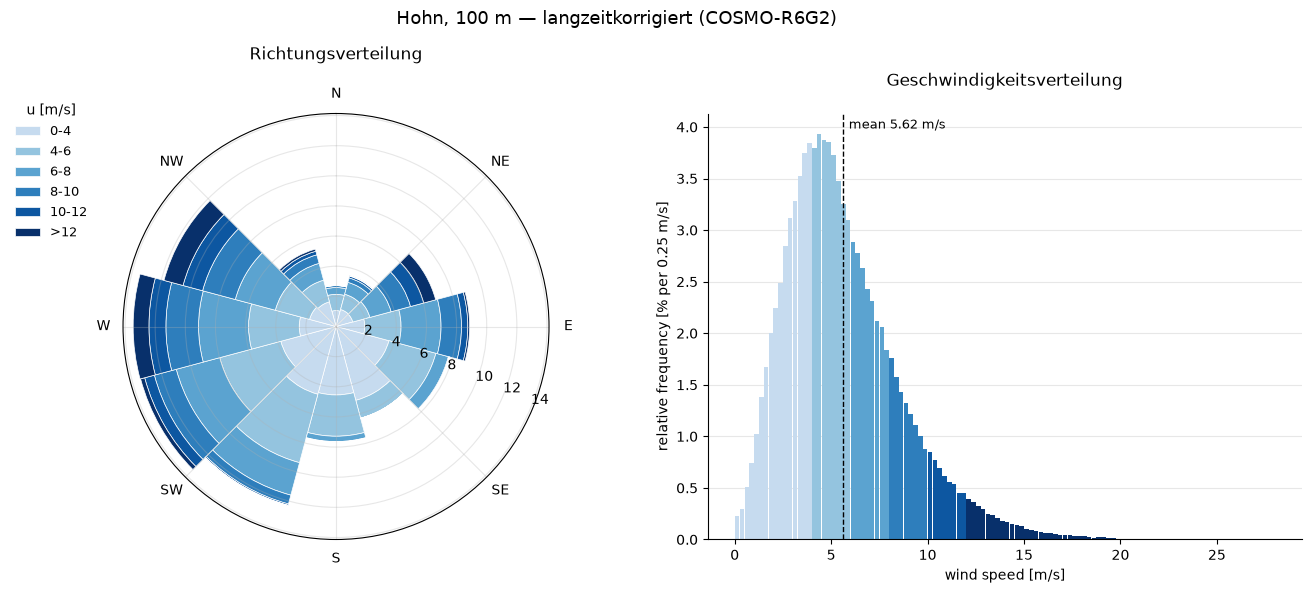


51 % of all hours come from between south-south-west and west-north-west (195°–315°), and that's
also where the strongest winds are, with sector 10 (WNW) averaging 7.6 m/s.
There's a smaller second peak from the east-north-east.


In [11]:
from windforecast.analysis.profile import windrose, speed_distribution

# --- both panels, one figure -------------------------------------------------
SPEED_BINS = (0, 4, 6, 8, 10, 12, np.inf)

fig = plt.figure(figsize=(14, 6))
ax_rose = fig.add_subplot(1, 2, 1, projection="polar")
ax_hist = fig.add_subplot(1, 2, 2)

_, rose = windrose(cosmo["sector"], predicted_sec["u"], speed_bins=SPEED_BINS,
                   ax=ax_rose, title="Richtungsverteilung")
_, dist = speed_distribution(predicted_sec["u"], bin_width=0.25, speed_bins=SPEED_BINS,
                             ax=ax_hist, title="Geschwindigkeitsverteilung")

# the rose already carries the class legend; keep one for the figure
ax_rose.legend(title="u [m/s]", loc="upper left", bbox_to_anchor=(-0.28, 1.05),
               frameon=False, fontsize=9)

fig.suptitle("Hohn, 100 m — langzeitkorrigiert (COSMO-R6G2)", fontsize=13)
fig.tight_layout()
plt.show()

freq = 100 * predicted_sec["sector"].value_counts(normalize=True).sort_index()
display(Markdown(f"""
{freq.loc[7:10].sum():.0f} % of all hours come from between south-south-west and west-north-west (195°–315°), and that's
also where the strongest winds are, with sector 10 (WNW) averaging {predicted_sec.groupby('sector')['u'].mean()[10]:.1f} m/s.
There's a smaller second peak from the east-north-east.
"""))


<details>
<summary>Two things about the long-term correction:</summary>

**1. Persistence is assumed.** Everything above describes
2002–2025. What the assessment needs is the mean over the turbines' operating
life, roughly the next 20 years. DFBEW II.3 states the assumption behind it: *"Dabei
wird unterstellt, dass die Langzeitdaten repräsentativ für die Zukunft sind …
Dies impliziert, dass keine langjährigen Trends auftreten dürfen."*

It is a claim about the future, so no amount of past data verifies it. The necessary condition, no trend in the reference data, isn't checked here.

**2. Only one long-term reference is used.** DFBEW II.3.2 notes that comparing several
long-term datasets reduces the risk of a faulty correlation.
</details>

Now that we have the predicted wind speeds, it might seem we could plug them directly into the turbines' power curve, but there are still a couple of small corrections to make before that happens. And as we'll see in Steps 4 and 5, small corrections can lead to big changes in the energy output.

## Step 4 — Horizontal transfer to the turbines (Horizontale Übertragung · DFBEW II.4 · MEASNET 8.4)

So far we have worked out the wind climate at one location: the station. But wind farms can be large, with kilometres between the turbines and the measurement. That might seem like a minor detail, but wind can change a lot within a couple of kilometres, especially in complex terrain. And small differences add up: a turbine's power goes with the cube of the wind speed, so a few percent more or less wind turns into roughly twice that in energy (DFBEW III.2 puts this factor at 1.5–2.5). That's often the difference between a project that pays off and one that doesn't. A real assessment therefore moves the wind from the measurement point to each turbine with a flow model.

DFBEW II.4 calls for a microscale flow model (*"lineare Modelle (WAsP) oder CFD-Modelle"*) driven by terrain height, surface roughness and obstacles. Those would be the best choices here, but they are mostly commercial, so the **Global Wind Atlas** stands in for them. GWA's maps at about 250 m (version 4) *are* the output of a WAsP microscale calculation (PyWAsP, driven by WRF mesoscale runs over ERA5 for 2008–2017), published for free under CC BY 4.0. Its absolute speeds come from its own model chain, not from our measurement, so I only take the relative difference between two points so that we have the model's spatial pattern, with our own level.

$$\text{factor} = \frac{\text{GWA(turbine)}}{\text{GWA(station)}}$$

GWA can't transfer *our* measured climate, because GWA is an independent model field, not a tool we feed data into. It gives the horizontal gradient and nothing more, and it inherits whatever the GWA model gets wrong at 250 m. That includes its own roughness map: whether GWA sees the forest north of the station the same way my $z_0$ choice in Step 1 does is something I can't check from here.

Next, I download and load GWA's mean wind speed at 100 m for the station and each turbine:

In [12]:
# --- Download GWA wind speed: -----------------------------------------------
# from windforecast.download.gwa import main as download_gwa

# download_gwa()   # writes DEU_wind-speed_<h>m.tif into data/raw/gwa/, skips what is there

And then find the factors between the gridpoints where the turbines are:

In [13]:
from windforecast.io.gwa import transfer_factors

TARGET_HEIGHT = 100   # hub height

turbines = [(t["latitude"], t["longitude"]) for t in site["turbines"]]
names = [t["name"] for t in site["turbines"]]

transfer = transfer_factors(
    (site["latitude"], site["longitude"]), turbines,
    height=TARGET_HEIGHT, names=names,
)
display(transfer)

# numbers for the text

max = transfer["factor"].idxmax()
min = transfer["factor"].idxmin()
min_val = 100 * (transfer.loc[min, "factor"] - 1)
max_val = 100 * (transfer.loc[max, "factor"] - 1)
gwa_station = transfer["gwa_station_100m"].iloc[0]
u_lt = predicted_sec["u"].mean()
gap = 100 * (1 - u_lt / gwa_station)

display(Markdown(f"""
Each turbine now has a factor: how much stronger or weaker the wind is there than at the station, according to GWA.
They're all within about ±1 % ({min} {min_val:+.1f} %, {max} {max_val:+.1f} %), which makes sense over open, flat grassland.
Small, but with the energy factor of 1.5–2.5 from above, ±1 % in wind is about ±2 % in energy.
These factors come back in Step 6.

A note on levels: GWA says {gwa_station:.2f} m/s at 100 m at the station, and our long-term series says
{u_lt:.2f} m/s, about {gap:.0f} % lower. Part of that is simply different models and periods (GWA covers 2008–2017),
and it's exactly why I only take ratios from GWA. But it's also a warning about Step 1. Lázár et al. [5] tested a very
similar log-profile extrapolation against measurements and found it underestimated the wind more than 70 % of the time,
with the largest misses at night under stable conditions, when, as I read it, the wind higher up decouples from the ground.
They extrapolated from 50 m; from 10 m the effect is probably larger, since the extrapolation uncertainty grows with the
height ratio (DFBEW [1] Table 2: 1.1–6.3 %; Waars [4] §2.1.4). Their errors are smaller than our gap, so this points in
the same direction rather than explaining all of it. Either way, read the absolute energy numbers at the end as conservative.

DFBEW [1] (III.1) is clear about this kind of error: *"Systematische Fehler dürfen bei der Windpotenzialbestimmung
nicht auftreten oder müssen korrigiert werden."* Systematic errors must not occur, or they have to be corrected.
MEASNET [2] 8.6 agrees: a known bias belongs in its own correction, not in the uncertainty. I haven't corrected it yet,
but I'll come back to it in a later update of this notebook.
"""))


,lat,lon,distance_km,gwa_100m,factor,gwa_station_100m
turbine,,,,,,
T1,54.311191,9.515405,1.598253,8.133293,1.007980,8.068907
T2,54.312005,9.524181,1.039351,8.098402,1.003655,8.068907
T3,54.313294,9.533644,0.451249,8.064533,0.999458,8.068907
T4,54.314295,9.543214,0.371970,8.072826,1.000486,8.068907
T5,54.315347,9.551840,0.870442,8.026122,0.994698,8.068907



Each turbine now has a factor: how much stronger or weaker the wind is there than at the station, according to GWA.
They're all within about ±1 % (T5 -0.5 %, T1 +0.8 %), which makes sense over open, flat grassland.
Small, but with the energy factor of 1.5–2.5 from above, ±1 % in wind is about ±2 % in energy.
These factors come back in Step 6.

A note on levels: GWA says 8.07 m/s at 100 m at the station, and our long-term series says
5.62 m/s, about 30 % lower. Part of that is simply different models and periods (GWA covers 2008–2017),
and it's exactly why I only take ratios from GWA. But it's also a warning about Step 1. Lázár et al. [5] tested a very
similar log-profile extrapolation against measurements and found it underestimated the wind more than 70 % of the time,
with the largest misses at night under stable conditions, when, as I read it, the wind higher up decouples from the ground.
They extrapolated from 50 m; from 10 m the effect is probably larger, since the extrapolation uncertainty grows with the
height ratio (DFBEW [1] Table 2: 1.1–6.3 %; Waars [4] §2.1.4). Their errors are smaller than our gap, so this points in
the same direction rather than explaining all of it. Either way, read the absolute energy numbers at the end as conservative.

DFBEW [1] (III.1) is clear about this kind of error: *"Systematische Fehler dürfen bei der Windpotenzialbestimmung
nicht auftreten oder müssen korrigiert werden."* Systematic errors must not occur, or they have to be corrected.
MEASNET [2] 8.6 agrees: a known bias belongs in its own correction, not in the uncertainty. I haven't corrected it yet,
but I'll come back to it in a later update of this notebook.


## Step 5 — Air density at hub height (Luftdichte · DFBEW II · MEASNET 9.2)

For the next correction, let's take another look at the power equation for wind turbines:

$$P = \tfrac{1}{2}\,\rho\,A\,u^3$$

with $A$ the rotor area, $\rho$ the air density and $u$ the wind speed. This tells us that denser air carries more energy at the same wind speed. Manufacturers provide power curves for their turbines, and they usually assume a standard air density. But there is a way to account for changes in air density.

<details>
<summary>What is a power curve?</summary>

A power curve is the manufacturer's table of how much electrical power the turbine delivers at each wind speed at hub height. It starts at the cut-in speed (around 3 m/s), rises steeply, levels off at rated power and drops to zero at the cut-out speed (~25 m/s), where the turbine shuts down to protect itself. It is measured for one reference air density. 

</details>

Air density depends on temperature, pressure and humidity, so it changes all the time: cold winter air is noticeably denser than a warm summer afternoon. For a pitch-regulated turbine like the N100, IEC 61400-12-1 accounts for this by adjusting the wind speed instead of the power (Floors & Nielsen [3], Eq. 18):

$$u_{\text{eq}} = u \left(\frac{\rho_{\text{site}}}{\rho_0}\right)^{1/3}$$

where $\rho_0$ is the density the power curve was measured at.

The three variables are normally measured on site as part of the campaign (DFBEW II: *"Zusätzlich werden Druck, Temperatur und Luftfeuchte erfasst, um die Luftdichte zu ermitteln."*). Floors & Nielsen [3], however, found that ERA5 reanalysis estimates air density as well as or better than nearby stations, and recommend it unless good measurements exist within about 10 km; and, unlike our wind speed in Step 3, a reanalysis needs no long-term correction. Assuming COSMO, as a higher-resolution regional reanalysis, does at least as well, this project uses it for all three variables, from the same grid cell and the same 24 years as the wind. The download follows:

In [14]:
# --- Download COSMO 1hrPt_tas, 1hrPt_ps and 1hrPt_huss: -------------------------------------
# download_group(
#     cfg["reference_data"]["cosmo"]["base_url"],
#     "thermo",
#     ["1hrPt_tas", "1hrPt_ps", "1hrPt_huss"],
#     site["latitude"], site["longitude"],
# )   # skips months already in the CSV; writes data/raw/cosmo/hourly/<var>/cosmo_<var>.csv


Next we create a data frame for the thermodynamic COSMO data and check the availability. 

In [15]:
from windforecast.paths import RAW_COSMO_THERMO

parts = []
for var in ["1hrPt_tas", "1hrPt_ps", "1hrPt_huss"]:
    df = pd.read_csv(RAW_COSMO_THERMO / var / f"cosmo_{var}.csv", index_col="time", parse_dates=True)
    parts.append(df.iloc[:, 0].rename(var.replace("1hrPt_", "")))

cosmo_thermo = pd.concat(parts, axis=1).sort_index()

print(f"{cosmo_thermo.index.min()} .. {cosmo_thermo.index.max()}  "
      f"({len(cosmo_thermo)} rows)")

expected = pd.date_range(cosmo_thermo.index.min(), cosmo_thermo.index.max(), freq="h")
print(f"expected hours {len(expected)}, missing timestamps {len(expected.difference(cosmo_thermo.index))}")
print(f"duplicated timestamps {cosmo_thermo.index.duplicated().sum()}\n")

print("availability per column (% of rows with a value):")
print((100 * cosmo_thermo.notna().mean()).round(2).to_string())
print()
print(cosmo_thermo.describe().round(4).to_string())


display(Markdown(f"""
Everything here looks good!
"""))

2002-01-01 01:00:00 .. 2026-07-01 00:00:00  (214728 rows)
expected hours 214728, missing timestamps 0
duplicated timestamps 0

availability per column (% of rows with a value):
tas     100.0
ps      100.0
huss    100.0

               tas           ps         huss
count  214728.0000  214727.0000  214728.0000
mean      282.8801  101373.5987       0.0064
std         7.0383    1029.6636       0.0026
min       258.9460   96735.0938       0.0009
25%       277.6813  100756.1641       0.0044
50%       282.7346  101430.9688       0.0060
75%       288.1861  102038.9609       0.0083
max       309.1142  104808.5156       0.0191



Everything here looks good!


Since COSMO gives temperature and humidity at 2 m and pressure at the surface, but the hub sits at 100 m, I lift the variables the same way Floors & Nielsen [3] do (their Eq. 8): the virtual temperature $T_v = T(1 + 0.61\,q)$ drops with the standard lapse rate of −0.0065 K/m (they found about −0.0056 K/m for Germany from ERA5, close enough), pressure follows the hydrostatic relation, and density is $\rho = p / (R_d\,T_v)$. 

This gives every hour of our predicted time series its own air density:

In [16]:
R_D, G0, L = 287.05, 9.80665, -0.0065

def density_at(df, from_height, to_height):
    Tv1 = df["tas"] * (1 + 0.61 * df["huss"])
    dz = to_height - from_height
    Tv2 = Tv1 + L * dz
    P2 = df["ps"] * (Tv2 / Tv1) ** (-G0 / (R_D * L))
    return P2 / (R_D * Tv2)

cosmo_thermo["rho_100m"] = density_at(cosmo_thermo, from_height=2.0, to_height=100.0)
predicted_sec["rho_100m"] = cosmo_thermo["rho_100m"]
rho_mean = predicted_sec["rho_100m"].mean()

display(predicted_sec.head())

display(Markdown(f"""
So this is what our table looks like. On average, the air at 100 m is **{rho_mean:.3f} kg/m³**.
The next step is to plug it into the equation for each turbine (and don't forget the turbine factor from Step 4)
to get the energy yield of our wind farm!
"""))


,u,sector,rho_100m
time,,,
2002-01-01 00:00:00,8.276346,10,NaN
2002-01-01 01:00:00,7.555978,10,1.293366
2002-01-01 02:00:00,6.873232,10,1.293020
2002-01-01 03:00:00,7.165538,10,1.297256
2002-01-01 04:00:00,5.271836,9,1.291369



So this is what our table looks like. On average, the air at 100 m is **1.232 kg/m³**.
The next step is to plug it into the equation for each turbine (and don't forget the turbine factor from Step 4)
to get the energy yield of our wind farm!


## Step 6 — Gross energy yield (Bruttoertrag · DFBEW II.5 · MEASNET 10.2)

Now everything comes together. To turn wind into energy I need two things: how often each wind speed occurs, and how much power the turbine makes at that speed.

The obvious way would be to go hour by hour: take each of the 24 years of predicted wind speeds, plug it into the power curve and add everything up. But remember what we're after. The turbines will run in the future, and the future won't repeat the past hour by hour. What we can expect to repeat is the *statistics* of the wind: how often each wind speed occurs, and from which direction. So instead of the exact time series, I fit a Weibull distribution per sector to the long-term wind (A = scale, k = shape), the standard way to describe how often each wind speed occurs. For the second ingredient, I use the power curve, corrected for each sector's air density from Step 5. Together they give the gross AEP:

$$AEP_\text{gross} = 8766 \sum_s f_s \sum_i p_{s,i}\; P\!\left(u_i\,(\rho_s/\rho_0)^{1/3}\right)$$

with $f_s$ the frequency of sector $s$, $p_{s,i}$ the probability of the 1 m/s bin $i$ in that sector, $u_i$ the bin's wind speed, $\rho_s$ the sector's mean air density and $\rho_0$ the power curve's reference density.

The hour-by-hour approach doesn't go to waste, though. A Weibull fit is a simplification, so MEASNET 10.2 asks to check it, and the easiest check is exactly that: run the power curve straight over the long-term hourly series and compare.


In [17]:
# fit one Weibull distribution per sector to the predicted long-term wind
from scipy import stats

rows = {}
for s, g in predicted_sec.groupby("sector"):
    u = g["u"][g["u"] > 0]
    k, _, A = stats.weibull_min.fit(u, floc=0)
    rows[s] = {"A": A, "k": k, "n": len(g),
               "freq": len(g) / len(predicted_sec),
               "u_mean": g["u"].mean(),
               "rho": g["rho_100m"].mean()}

weibull = pd.DataFrame(rows).T
display(weibull.round(4))


display(Markdown(f"""
This table is the input for the energy calculation. For each of the {len(weibull)} sectors it holds the Weibull
parameters (A, k), how often the wind comes from that sector (freq) and the mean air density there (rho),
all based on {int(weibull['n'].sum()):,} long-term hours."""))

,A,k,n,freq,u_mean,rho
0,5.2750,2.7121,5744.0,0.0273,4.6877,1.2433
1,5.9483,2.2699,7337.0,0.0349,5.2646,1.2458
2,8.6199,2.1676,14403.0,0.0685,7.6532,1.2347
3,6.8273,2.5456,18651.0,0.0887,6.0742,1.2368
4,4.6336,2.8736,16362.0,0.0778,4.1292,1.2379
5,3.4955,3.5955,13267.0,0.0631,3.1476,1.2350
6,4.1060,2.7317,16133.0,0.0767,3.6540,1.2307
7,5.2236,2.3691,25873.0,0.1230,4.6357,1.2297
8,6.3781,2.1795,28248.0,0.1343,5.6537,1.2265
9,7.7966,2.2125,28320.0,0.1346,6.9082,1.2260



This table is the input for the energy calculation. For each of the 12 sectors it holds the Weibull
parameters (A, k), how often the wind comes from that sector (freq) and the mean air density there (rho),
all based on 210,383 long-term hours.

In [18]:
# Nordex N100/2500 power curve at 1.225 kg/m³ (Staffell (no year) [6])
from windforecast.paths import CONFIG

pc = pd.read_csv(CONFIG / cfg["turbine"]["power_curve"])
ws, kw = pc["wind_speed_ms"].to_numpy(), pc["power_kw"].to_numpy()

RHO_REF = cfg["turbine"]["power_curve_reference_density"]   # density the curve is valid for
P_RATED = kw.max()                                          # rated power in kW
CUT_OUT = ws[kw > 0].max()                                  # 25 m/s

def power_curve(u):
    u = np.asarray(u, dtype=float)
    return np.where(u > CUT_OUT, 0.0, np.interp(u, ws, kw, left=0.0, right=0.0))

display(Markdown(f"""
Here we read the power curve and create a function that takes any set of wind speeds and returns the power the
turbine would produce at each, interpolating linearly between the tabulated points. 
"""))


Here we read the power curve and create a function that takes any set of wind speeds and returns the power the
turbine would produce at each, interpolating linearly between the tabulated points. 


In [19]:
bins = np.arange(0, 30.5, 1.0)                       # 1 m/s wind speed bins
centres = (bins[:-1] + bins[1:]) / 2

def turbine_aep(factor=1.0):
    """Gross AEP in kWh/yr from the sector Weibull fits."""
    aep = 0.0
    for s, row in weibull.iterrows():
        cdf = stats.weibull_min.cdf(bins, row["k"], loc=0, scale=row["A"] * factor)
        p = np.diff(cdf)                                         # probability of each bin
        u_eq = centres * (row["rho"] / RHO_REF) ** (1/3)         # density correction (Step 5)
        aep += row["freq"] * (p * power_curve(u_eq)).sum()       # weighted by sector frequency
    return aep * 8766

# all five turbines, each with its own GWA factor (Step 4)
transfer["aep_MWh"] = [turbine_aep(f) / 1e3 for f in transfer["factor"]]
farm_GWh = transfer["aep_MWh"].sum() / 1e3
spread = 100 * (transfer.loc["T1", "aep_MWh"] / transfer.loc["T5", "aep_MWh"] - 1)

# one turbine at the station, for comparison
aep_station = turbine_aep(1.0)
flh = aep_station / P_RATED

display(Markdown(f"""
MEASNET 10.2: the gross yield is calculated per turbine, and the farm is simply the sum. This is where the GWA factors
from Step 4 come in. Multiplying every wind speed by a factor f stretches the Weibull distribution: A becomes f·A,
and k stays the same. So each turbine gets the same calculation with its own A.
"""))

display(transfer[["distance_km", "factor", "aep_MWh"]].round({"distance_km": 2, "factor": 3, "aep_MWh": 1}))

display(Markdown(f"""
The farm produces **{farm_GWh:.1f} GWh per year** gross. T1 is the best spot and T5 the weakest,
a spread of {spread:.1f} %.

For comparison, one turbine standing right at the station would produce {aep_station / 1e6:.2f} GWh per year.
That's about {flh:,.0f} full-load hours: the number of hours it would have to run at its full rated power
({P_RATED:,.0f} kW) to produce the same energy. Divided by the 8766 hours in a year, that gives the capacity factor
of {100 * flh / 8766:.0f} %, the share of its maximum possible output the turbine actually delivers.
"""))


MEASNET 10.2: the gross yield is calculated per turbine, and the farm is simply the sum. This is where the GWA factors
from Step 4 come in. Multiplying every wind speed by a factor f stretches the Weibull distribution: A becomes f·A,
and k stays the same. So each turbine gets the same calculation with its own A.


,distance_km,factor,aep_MWh
turbine,,,
T1,1.60,1.008,5146.1
T2,1.04,1.004,5097.6
T3,0.45,0.999,5050.6
T4,0.37,1.000,5062.1
T5,0.87,0.995,4997.3



The farm produces **25.4 GWh per year** gross. T1 is the best spot and T5 the weakest,
a spread of 3.0 %.

For comparison, one turbine standing right at the station would produce 5.06 GWh per year.
That's about 2,023 full-load hours: the number of hours it would have to run at its full rated power
(2,500 kW) to produce the same energy. Divided by the 8766 hours in a year, that gives the capacity factor
of 23 %, the share of its maximum possible output the turbine actually delivers.


In [20]:
# time-series check (MEASNET 10.2): power curve straight over the long-term hourly series
u_ts = predicted_sec["u"]
rho_ts = predicted_sec["rho_100m"].fillna(predicted_sec["rho_100m"].mean())   # 2 missing hours
years = len(predicted_sec) / 8766

def turbine_aep_ts(factor=1.0):
    """Gross AEP in kWh/yr from the hourly long-term series."""
    return power_curve(factor * u_ts * (rho_ts / RHO_REF) ** (1/3)).sum() / years

farm_ts_GWh = sum(turbine_aep_ts(f) for f in transfer["factor"]) / 1e6
check = 100 * (farm_GWh / farm_ts_GWh - 1)

display(Markdown(f"""
The time-series check gives {farm_ts_GWh:.1f} GWh per year for the farm, a difference of {check:+.1f} %,
{'small enough to trust the Weibull fit for the energy calculation' if abs(check) < 2 else 'large enough to look into the Weibull fit before going further'}.
"""))


The time-series check gives 24.9 GWh per year for the farm, a difference of +1.6 %,
small enough to trust the Weibull fit for the energy calculation.


### What "gross" means, and what comes next

This is **gross** in the sense of DFBEW II.5 and MEASNET 10.2: what the turbines would produce if nothing ever got in the way. The real number (net) is lower, and how much lower depends on the layout, the permit and the site:

- **Wakes.** Turbines steal wind from each other, typically 3–15 % (DFBEW II.5), more when they stand closer than about 10 rotor diameters in the main wind direction. Our five stand in a nearly west–east row about 600 m (≈ 6 rotor diameters) apart, and the most common wind comes from the west. So the wind often blows straight down the row, and I'd expect the wake losses to be on the high side.
- **Availability.** Maintenance and faults cost around 3 %. Electrical losses up to the grid connection are around 2–3 % (DFBEW II.5).
- **Curtailment.** Shutdowns for noise, shadow flicker or bats, depending on what the permit says.
- **Environment.** Icing, dirt on the blades, and trees growing nearby.

After that comes the uncertainty budget (DFBEW III, MEASNET 8.6), which turns this single number into a P50 and a P90. In WindPRO, wakes would be done in PARK, noise in DECIBEL and shadow flicker in SHADOW. Here I'll try to get there without paid software.